In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from imblearn.over_sampling import SMOTE

import joblib

In [2]:
df = pd.read_csv("../data/processed/clean_forestfire.csv")

df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,fire
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0


In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
 13  fire    517 non-null    int64  
dtypes: float64(8), int64(4), object(2)
memory usage: 56.7+ KB


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,fire
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292,0.522244
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818,0.499989
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000,1.000000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000,1.000000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000,1.000000


In [6]:
df.isnull().sum()

df.fillna(df.median(numeric_only=True), inplace=True)

In [7]:
df["fire"] = (df["area"] > 0).astype(int)

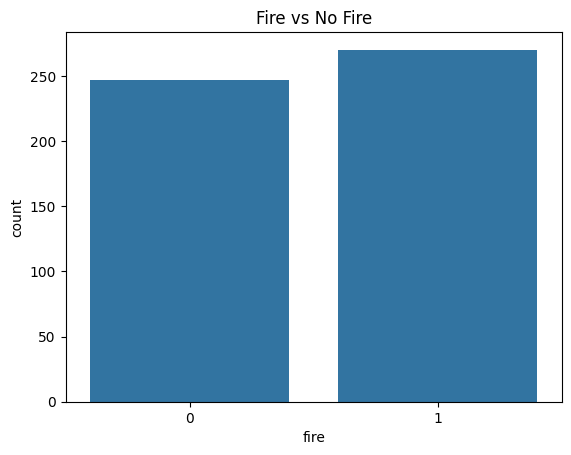

fire
1    0.522244
0    0.477756
Name: proportion, dtype: float64


In [8]:
sns.countplot(x=df["fire"])

plt.title("Fire vs No Fire")

plt.show()

print(df["fire"].value_counts(normalize=True))

In [9]:
df["dryness_index"] = df["temp"] / (df["RH"] + 1)

In [10]:
df["humidity_deficit"] = 100 - df["RH"]

In [11]:
df["no_rain"] = (df["rain"] == 0).astype(int)

In [12]:
df["heat_stress"] = df["temp"] * df["wind"]

In [13]:
df["vegetation_dryness"] = df["FFMC"] * df["DMC"]

In [14]:
month_map = {
    "jan":1, "feb":2, "mar":3, "apr":4,
    "may":5, "jun":6, "jul":7, "aug":8,
    "sep":9, "oct":10, "nov":11, "dec":12
}

df["month_num"] = df["month"].map(month_map)

In [15]:
day_map = {
    "mon":1,
    "tue":2,
    "wed":3,
    "thu":4,
    "fri":5,
    "sat":6,
    "sun":7
}

df["day_num"] = df["day"].map(day_map)

In [16]:
df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)

df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

In [17]:
drop_cols = ["month", "day", "area"]

df.drop(columns=drop_cols, inplace=True)

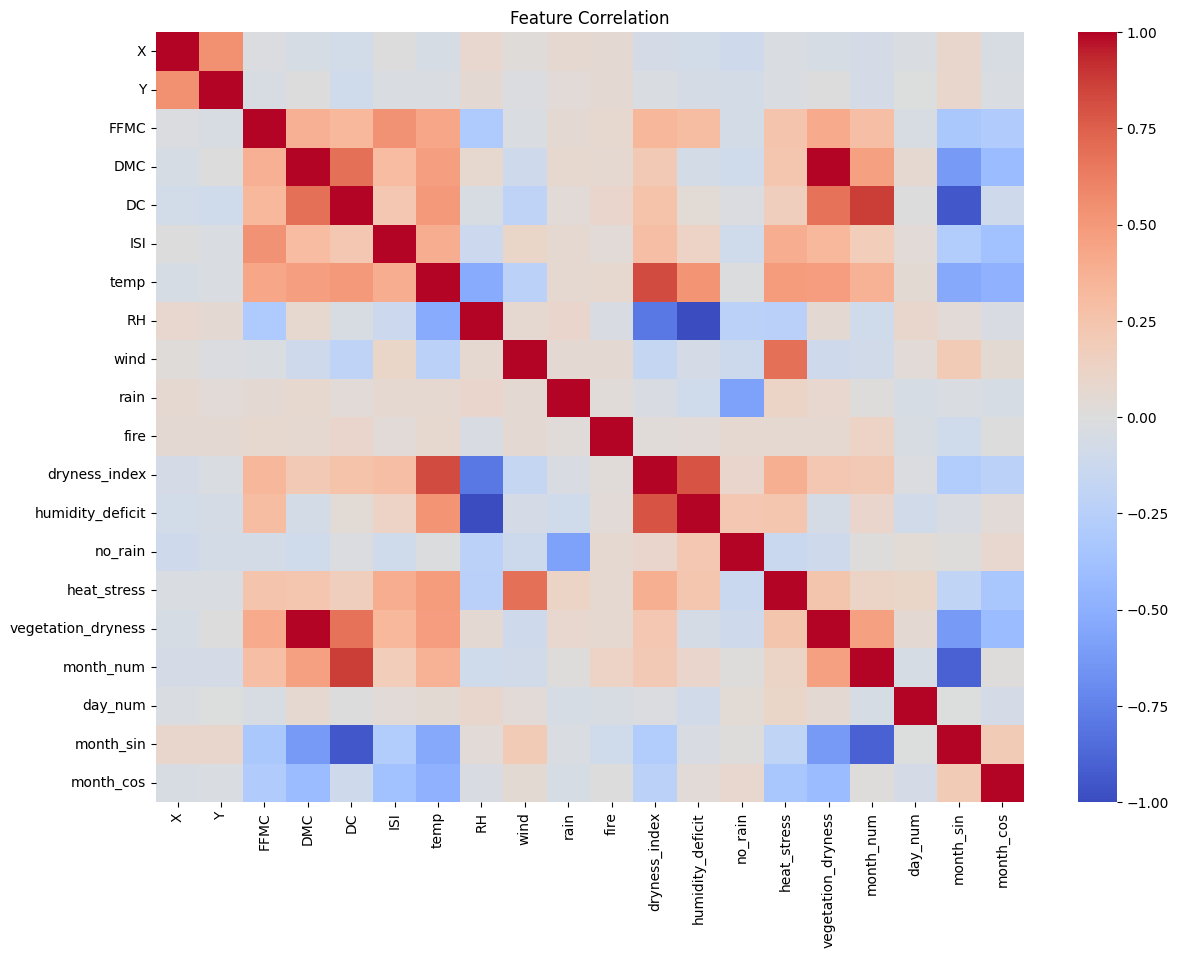

In [18]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

In [19]:
X = df.drop("fire", axis=1)

y = df["fire"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

d:\Forest Fire prediction\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [22]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

fire
1    216
0    197
Name: count, dtype: int64
fire
1    216
0    216
Name: count, dtype: int64


In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [24]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [25]:
X_train_scaled.to_csv("../data/final/X_train.csv", index=False)

X_test_scaled.to_csv("../data/final/X_test.csv", index=False)

y_train_smote.to_csv("../data/final/y_train.csv", index=False)

y_test.to_csv("../data/final/y_test.csv", index=False)

In [26]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [27]:
df.to_csv(
    "../data/processed/featured_dataset.csv",
    index=False
)